# Micro-organism Image Classification — EfficientNetB0 with Fine-Tuning

**Why this notebook?** The other microorganism notebook used a frozen `MobileNetV2` base model. This
one uses two upgrades that usually push accuracy higher:

1. **A stronger pretrained base model: `EfficientNetB0`.** EfficientNet is a newer, more efficient
   architecture family than MobileNetV2 — for a similar or smaller number of parameters, it tends to
   reach higher accuracy on image classification tasks. It also comes pretrained on ImageNet.
2. **Fine-tuning, not just frozen transfer learning.** In the frozen MobileNetV2 notebook, the entire
   base model stayed frozen and only the new head was trained. This time we train in **two phases**:
   - **Phase 1:** freeze the whole base model (same idea as before) and train only the new head, so
     it starts out reasonably good instead of random.
   - **Phase 2 (fine-tuning):** unfreeze the *last part* of the base model and continue training
     everything together, using a very small learning rate. This lets the deepest layers of
     EfficientNetB0 adjust slightly to microscope images specifically, on top of everything it
     already knows from ImageNet — usually the single biggest accuracy boost you can get in transfer
     learning.

We also use **class weights**, which tell the model to pay more attention to micro-organism types
that have fewer training images, so it doesn't get lazy and just favor the most common type.

Same structure as the other notebooks: dataset exploration, sample visualization, data preparation,
model building, training with callbacks, plotting results, evaluating, testing on samples, and saving
the model. Every cell has a short explanation and inline comments, kept beginner-friendly.

## Step 1: Import the Libraries

Same as the MobileNetV2 notebook, plus:
- `EfficientNetB0` and its matching `preprocess_input` function, instead of MobileNetV2.
- `sklearn.utils.class_weight` — used to compute class weights that account for any imbalance
  between how many images each micro-organism type has.

In [1]:
# Basic Python tools for handling files and folders
import os
from pathlib import Path

# Numerical operations
import numpy as np

# For plotting images and graphs
import matplotlib.pyplot as plt

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Used to compute class weights for imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

I0000 00:00:1785286735.758757   93222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785286737.906133   93222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785286790.363110   93222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## Step 2: Set the Dataset Path and Basic Parameters

- `IMG_HEIGHT`, `IMG_WIDTH` — 224x224, the standard input size `EfficientNetB0` expects.
- `PHASE1_EPOCHS` — how long we train with the base model frozen.
- `PHASE2_EPOCHS` — how long we continue training during fine-tuning.
- `FINE_TUNE_LAYERS` — how many of the base model's final layers to unfreeze during fine-tuning.

**Important:** Update `DATASET_DIR` below if your folder path is different.

In [2]:
# Path to the main dataset folder (one sub-folder per micro-organism type).
DATASET_DIR = Path(r"/home/asus/projects/computer_vision/Micro-organism Classificationn/Micro_Organism")

# EfficientNetB0's standard input size
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

# Phase 1: train only the new head, with the base model frozen
PHASE1_EPOCHS = 10

# Phase 2: fine-tune the unfrozen part of the base model together with the head
PHASE2_EPOCHS = 15

# How many of EfficientNetB0's final layers to unfreeze during fine-tuning.
# We keep the earlier layers frozen because they hold very general, broadly useful features
# (edges, colors, simple textures) that don't need to change for a new dataset.
FINE_TUNE_LAYERS = 30

VALIDATION_SPLIT = 0.2
SEED = 42

## Step 3: Explore the Dataset

Check the micro-organism type names and how many images each one has. We'll reuse `image_counts`
further down to compute class weights.

In [3]:
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Number of micro-organism types (classes) found:", len(class_names))
for name in class_names:
    print(" -", name)

Number of micro-organism types (classes) found: 8
 - Amoeba
 - Euglena
 - Hydra
 - Paramecium
 - Rod_bacteria
 - Spherical_bacteria
 - Spiral_bacteria
 - Yeast


Number of images per micro-organism type:
 - Amoeba: 72 images
 - Euglena: 168 images
 - Hydra: 76 images
 - Paramecium: 152 images
 - Rod_bacteria: 85 images
 - Spherical_bacteria: 86 images
 - Spiral_bacteria: 75 images
 - Yeast: 75 images

Total images: 789


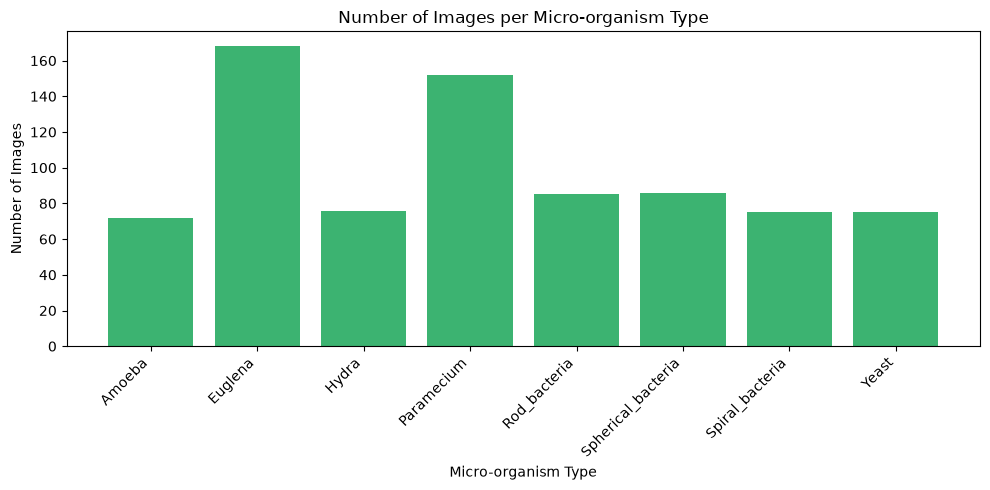

In [4]:
image_counts = {}

for class_name in class_names:
    class_folder = DATASET_DIR / class_name
    num_images = len([f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    image_counts[class_name] = num_images

print("Number of images per micro-organism type:")
for class_name, count in image_counts.items():
    print(f" - {class_name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values(), color="mediumseagreen")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Micro-organism Type")
plt.ylabel("Number of Images")
plt.title("Number of Images per Micro-organism Type")
plt.tight_layout()
plt.show()

## Step 4: Visualize Sample Images

A quick visual check that the images loaded correctly, and a reminder of what each micro-organism
type actually looks like under the microscope before we start building the model.

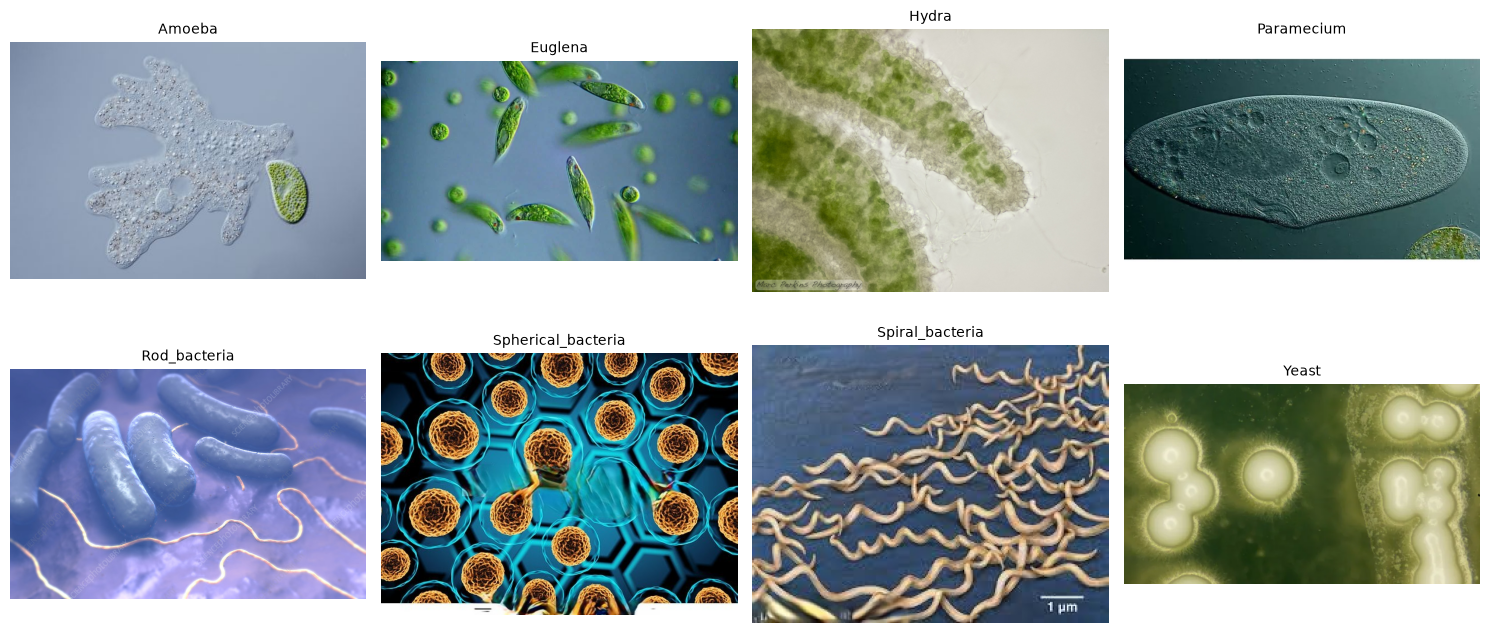

In [5]:
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name

    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    if len(image_files) == 0:
        continue
    sample_image_path = image_files[0]

    img = keras.preprocessing.image.load_img(sample_image_path)
    plt.subplot(3, 4, i + 1)  # Adjust grid size (rows, cols) if you have more/fewer classes
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Prepare the Data for Training

A couple of differences compared to the MobileNetV2 notebook:

- We use `preprocess_input` from `tensorflow.keras.applications.efficientnet` instead of a plain
  `rescale=1./255`. Every pretrained model expects its input prepared in the exact way it was
  trained on — EfficientNet has its own specific preprocessing baked in, so using the matching
  function avoids feeding it data in a format it doesn't recognize.
- Augmentation settings are similar to before — random rotation, shifting, zoom, and flipping on the
  training data only.

In [6]:
# preprocess_input handles scaling the pixel values the exact way EfficientNetB0 expects.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

# Validation data: same preprocessing, no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

print("Class indices used by the model:", train_generator.class_indices)

Found 633 images belonging to 8 classes.
Found 156 images belonging to 8 classes.
Class indices used by the model: {'Amoeba': 0, 'Euglena': 1, 'Hydra': 2, 'Paramecium': 3, 'Rod_bacteria': 4, 'Spherical_bacteria': 5, 'Spiral_bacteria': 6, 'Yeast': 7}


## Step 6: Compute Class Weights

Looking back at the bar chart in Step 3, some micro-organism types likely have more images than
others. Without correcting for this, the model can get a misleadingly high accuracy just by favoring
whichever type has the most examples, while doing poorly on the rarer ones.

`compute_class_weight` gives each class a weight: types with fewer images get a *higher* weight, so
mistakes on those types count for more during training, encouraging the model to pay attention to
them too.

In [8]:
# train_generator.classes holds the numeric class label for every single training image
class_labels = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_generator.classes
)

# Keras expects class weights as a dictionary: {class_index: weight}
class_weights = dict(zip(class_labels, class_weights_array))

print("Class weights (higher = fewer training images for that type):")
for class_index, weight in class_weights.items():
    type_name = [name for name, idx in train_generator.class_indices.items() if idx == class_index][0]
    print(f" - {type_name}: {weight:.2f}")

Class weights (higher = fewer training images for that type):
 - Amoeba: 1.36
 - Euglena: 0.59
 - Hydra: 1.30
 - Paramecium: 0.65
 - Rod_bacteria: 1.16
 - Spherical_bacteria: 1.15
 - Spiral_bacteria: 1.32
 - Yeast: 1.32


## Step 7: Build the Model — EfficientNetB0 Base + Classification Head

Same overall idea as the MobileNetV2 notebook: load a pretrained base model without its original
classification layer, freeze it, and add our own head on top.

`include_top=False` removes EfficientNetB0's original 1000-class ImageNet output layer, and
`weights="imagenet"` loads its pretrained weights. We freeze it for Phase 1 so training only affects
the new head at first.

In [9]:
base_model = EfficientNetB0(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the entire base model for Phase 1
base_model.trainable = False

print("Number of layers in the base model:", len(base_model.layers))

I0000 00:00:1785287391.725454   93222 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Number of layers in the base model: 238


In [10]:
# The same style of classification head as the MobileNetV2 notebook
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

num_classes = len(class_names)
predictions = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

## Step 8: Phase 1 — Train the Head With the Base Model Frozen

We compile with a normal learning rate here, since only the new (randomly initialized) head is being
trained and it needs to move fairly quickly to start making sensible predictions.

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,571 (16.08 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
early_stop_phase1 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint_phase1 = ModelCheckpoint(
    "best_microorganism_effnet_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop_phase1, checkpoint_phase1]
)

Epoch 1/10


I0000 00:00:1785287447.257129   93222 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1785287456.342835   95377 service.cc:153] XLA service 0x7ba9b00345b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785287456.342878   95377 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785287456.801104   95377 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785287459.898226   95377 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1785287460.358518   95377 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16051__.255
E0000 00:00:1785287467.771608   95377 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup 

 3/20 ━━━━━━━━━━━━━━━━━━━━ 8s 501ms/step - accuracy: 0.1667 - loss: 2.1388

I0000 00:00:1785287498.004975   95377 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16051__.255
E0000 00:00:1785287503.569981   95377 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3697 - loss: 1.7541

E0000 00:00:1785287539.858388   95377 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.3697 - loss: 1.7541 - val_accuracy: 0.5769 - val_loss: 1.3324
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 757ms/step - accuracy: 0.6667 - loss: 1.0775 - val_accuracy: 0.6346 - val_loss: 1.1214
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 721ms/step - accuracy: 0.7314 - loss: 0.8725 - val_accuracy: 0.6538 - val_loss: 1.0536
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 761ms/step - accuracy: 0.7867 - loss: 0.6822 - val_accuracy: 0.6795 - val_loss: 1.0226
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 708ms/step - accuracy: 0.8389 - loss: 0.5545 - val_accuracy: 0.6923 - val_loss: 1.0389
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 762ms/step - accuracy: 0.8246 - loss: 0.5020 - val_accuracy: 0.6795 - val_loss: 1.0482
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 682ms/step - accuracy: 0.8657 - loss: 0.4553 - val_accuracy: 0.6923 - val_loss: 1.0454


## Step 9: Phase 2 — Fine-Tune the Base Model

Now we unfreeze the last `FINE_TUNE_LAYERS` layers of EfficientNetB0 and continue training, letting
those deeper layers adjust slightly to microscope-image-specific patterns.

**Very important:** we use a **much smaller learning rate** here (100x smaller than Phase 1). The
base model's weights are already well-trained from ImageNet — large updates at this stage would
destroy that useful knowledge instead of gently refining it. This is the single most important rule
of fine-tuning: unfreeze, but update very gently.

We also need to re-compile the model after changing which layers are trainable — Keras requires this
whenever `trainable` is changed on existing layers.

In [13]:
# Unfreeze the whole base model...
base_model.trainable = True

# ...then re-freeze everything except the last FINE_TUNE_LAYERS layers
fine_tune_at = len(base_model.layers) - FINE_TUNE_LAYERS
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfrozen layers: {len(base_model.layers) - fine_tune_at} out of {len(base_model.layers)}")

Unfrozen layers: 30 out of 238


In [14]:
# Re-compile with a much smaller learning rate now that more of the network can update
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,571 (16.08 MB)

 Trainable params: 1,661,160 (6.34 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [15]:
early_stop_phase2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint_phase2 = ModelCheckpoint(
    "best_microorganism_effnet_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# Gently reduce the learning rate further if validation loss plateaus during fine-tuning
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop_phase2, checkpoint_phase2, reduce_lr]
)

Epoch 1/15


I0000 00:00:1785287913.163285   95377 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45173__.283


 9/20 ━━━━━━━━━━━━━━━━━━━━ 6s 572ms/step - accuracy: 0.7292 - loss: 0.9707

I0000 00:00:1785287937.961014   95376 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45173__.283


20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7109 - loss: 0.9776 - val_accuracy: 0.6667 - val_loss: 1.0385 - learning_rate: 1.0000e-05
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 690ms/step - accuracy: 0.7267 - loss: 0.9476 - val_accuracy: 0.6603 - val_loss: 1.0524 - learning_rate: 1.0000e-05
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 705ms/step - accuracy: 0.7346 - loss: 0.9061 - val_accuracy: 0.6474 - val_loss: 1.0647 - learning_rate: 1.0000e-05
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 679ms/step - accuracy: 0.7393 - loss: 0.9002 - val_accuracy: 0.6410 - val_loss: 1.0809 - learning_rate: 5.0000e-06
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 707ms/step - accuracy: 0.7536 - loss: 0.8596 - val_accuracy: 0.6346 - val_loss: 1.0947 - learning_rate: 5.0000e-06


## Step 10: Plot the Full Training History (Both Phases Combined)

We stitch together the accuracy/loss curves from Phase 1 and Phase 2 into one continuous plot, with a
vertical line marking exactly where fine-tuning began. This makes it easy to see whether fine-tuning
actually helped push accuracy higher than Phase 1 alone achieved.

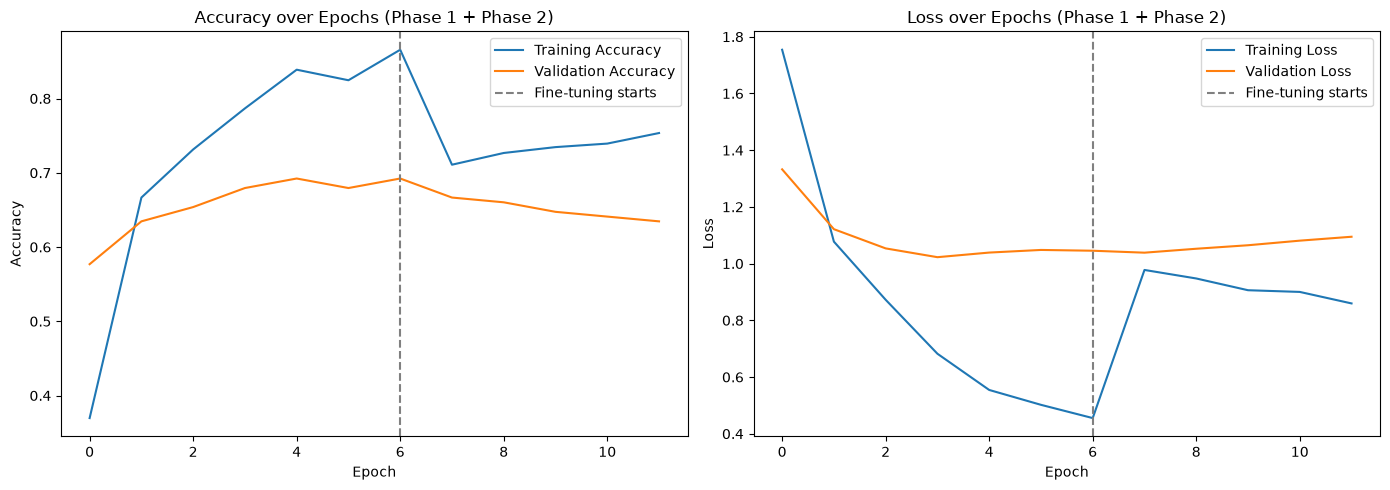

In [16]:
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]

phase1_len = len(history_phase1.history["accuracy"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.axvline(x=phase1_len - 1, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Accuracy over Epochs (Phase 1 + Phase 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.axvline(x=phase1_len - 1, color="gray", linestyle="--", label="Fine-tuning starts")
plt.title("Loss over Epochs (Phase 1 + Phase 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluate the Model

Check the final validation accuracy and loss. Compare this number to the frozen MobileNetV2 notebook
to see the effect of fine-tuning and a stronger base model.

In [17]:
val_loss_final, val_accuracy_final = model.evaluate(validation_generator)

print(f"Validation Loss: {val_loss_final:.4f}")
print(f"Validation Accuracy: {val_accuracy_final:.4f} ({val_accuracy_final * 100:.2f}%)")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.6667 - loss: 1.0385
Validation Loss: 1.0385
Validation Accuracy: 0.6667 (66.67%)


## Step 12: Test the Model on Some Sample Images

Same sanity check as before — predict micro-organism type for a batch of validation images and
compare to the true labels.

W0000 00:00:1785288033.922680   93222 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267584 bytes after encountering the first element of size 19267584 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


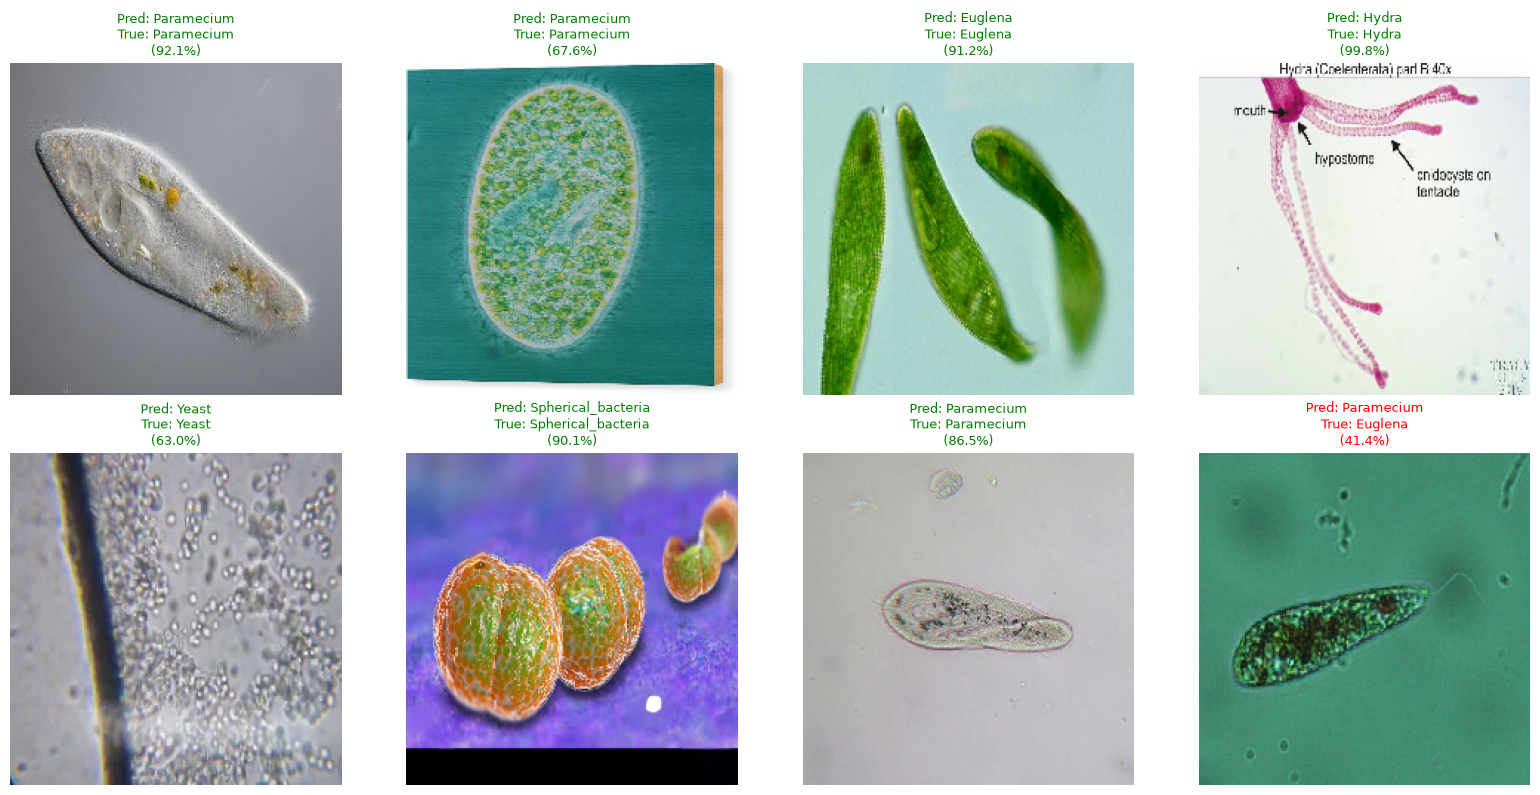

In [18]:
sample_images, sample_labels = next(validation_generator)
predictions = model.predict(sample_images)

index_to_class = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(16, 8))
num_to_show = min(8, len(sample_images))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)
    # Undo EfficientNet's preprocessing just enough to display the image reasonably.
    # (preprocess_input scales pixel values, so we normalize back into a displayable 0-1 range.)
    img_display = sample_images[i] - sample_images[i].min()
    img_display = img_display / (img_display.max() + 1e-8)
    plt.imshow(img_display)

    predicted_class = index_to_class[np.argmax(predictions[i])]
    true_class = index_to_class[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100

    color = "green" if predicted_class == true_class else "red"
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}\n({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 13: Save the Final Model

In [19]:
model.save("microorganism_efficientnet_finetuned.keras")
print("Model saved as microorganism_efficientnet_finetuned.keras")

Model saved as microorganism_efficientnet_finetuned.keras


## Comparing This Notebook to the Frozen MobileNetV2 Notebook

| | MobileNetV2 (frozen) | EfficientNetB0 (fine-tuned, this notebook) |
|---|---|---|
| Starting weights | Pretrained (frozen) | Pretrained, then partially unfrozen |
| Trainable parameters | Only the head (small) | Head + last 30 base layers |
| Handles class imbalance | No | Yes, via class weights |
| Typical accuracy | Good | Usually higher |
| Training time | Fast | Two phases, phase 2 needs care (small LR) |

## Next Steps / Ideas to Improve Further (Optional)

- **Unfreeze more layers**: try increasing `FINE_TUNE_LAYERS` (e.g. to 50 or 80) if you have enough
  data and training time, and see if validation accuracy improves further.
- **Try an even larger EfficientNet variant** (`EfficientNetB1`, `EfficientNetB2`) if you have a GPU
  and more training time.
- **Confusion matrix**: build one to see exactly which micro-organism types get confused with each
  other, which can point to where more training images would help most.
- **Test-time augmentation**: average predictions over a few augmented versions of each test image
  for slightly more robust predictions.

In [2]:
from IPython.display import display, Markdown

mobilenet_val_loss = 1.0590
mobilenet_val_accuracy = 0.6667

efficientnet_val_loss = 1.0385
efficientnet_val_accuracy = 0.6667

comparison_text = f"""
## Final Validation Comparison

These are the final validation metrics reported by each notebook using its own preprocessing pipeline.

| Model | Validation Loss | Validation Accuracy |
|---|---:|---:|
| MobileNetV2 (frozen) | {mobilenet_val_loss:.4f} | {mobilenet_val_accuracy * 100:.2f}% |
| EfficientNetB0 (fine-tuned) | {efficientnet_val_loss:.4f} | {efficientnet_val_accuracy * 100:.2f}% |

**Result:** EfficientNetB0 lowers validation loss by {mobilenet_val_loss - efficientnet_val_loss:.4f}, while both models reached the same validation accuracy on this run.
"""

display(Markdown(comparison_text))


## Final Validation Comparison

These are the final validation metrics reported by each notebook using its own preprocessing pipeline.

| Model | Validation Loss | Validation Accuracy |
|---|---:|---:|
| MobileNetV2 (frozen) | 1.0590 | 66.67% |
| EfficientNetB0 (fine-tuned) | 1.0385 | 66.67% |

**Result:** EfficientNetB0 lowers validation loss by 0.0205, while both models reached the same validation accuracy on this run.
